In [34]:
%load_ext autoreload
%autoreload 2

# Global libraries
import os
import torch
from torch.utils.data import DataLoader
from collections import defaultdict
from torchviz import make_dot 
from PIL import ImageFont
from torchinfo import summary

# Local libraries enivironment loading
import sys
from pathlib import Path
path_Project = Path(os.getcwd()).parent.parent
path_Git = path_Project.parent

def IncludeDirectory(path, index = 0, indexStop = -1):
    if(os.path.exists(path) and (index <= indexStop or indexStop == -1)):
        print(path)
        sys.path.append(path)
        children = os.listdir(path)
        for i in range(len(children)):
            pathChild = os.path.join(path,children[i])
            if(os.path.isdir(pathChild)):
                IncludeDirectory(pathChild, index + 1, indexStop)

# Activate the function
IncludeDirectory(path_Git,0,1)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\r.van.der.wal\Documents\GitHub
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT


In [53]:
# Local libraries
from src.constants import DEVICE
from src.models.tools.get_multi_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.dataset.load_dataset import load_dataset_total
from src.training.train_multi import move_batch_to_device, validate, get_output_results
from src.utils.loss_func.get_loss_function import get_loss_function
from src.visualization.Confusion_matrix import confusion_matrix_multi

In [61]:
# Install the following
#   - App:          graphviz
#   - Python Lib:   pip install graphviz
#   - Python Lib:   pip install torchviz

# Also set graphviz location to PATH
if(False):
    os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [78]:
# Load the configurations for the model
config = get_config('DETOXLung_config', pathGiven = str(path_Project))
config['general']['trialNumber'] = "Notebook_Test"
config['paths']['results'] = r"C:/Users/r.van.der.wal/Documents/"
# Load example dataset for input and output expectations of model
dataset, metadata = load_dataset_total(config)

# Get model
model = get_classification_model(config,metadata)
model.to(device=DEVICE)

c:\Users\r.van.der.wal\Documents\GitHub\pred_RT\src\config_presets\Base_config.yaml
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT\src\config_presets\DETOXLung_config.yaml
Patient collection --> Train: 572, Validation: 156
Patient collection --> Test: 308


c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


MultiTox_Classifier(
  (encoder): DCNN_Pooling(
    (first_conv_blocks): ModuleList()
    (conv_blocks): ModuleList(
      (0): small_conv_block(
        (pad): conv3d_padding_same()
        (conv1): Conv3d(3, 8, kernel_size=(7, 7, 7), stride=(1, 1, 1))
        (activation1): LeakyReLU(negative_slope=0.1)
        (norm1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (pool): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
      )
      (1): small_conv_block(
        (pad): conv3d_padding_same()
        (conv1): Conv3d(8, 8, kernel_size=(5, 5, 5), stride=(1, 1, 1))
        (activation1): LeakyReLU(negative_slope=0.1)
        (norm1): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (pool): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
      )
      (2): small_conv_block(
        (pad): conv3d_padding_same()
        (conv1)

In [62]:
outputs = None
train_loader = DataLoader(dataset[0][0], batch_size=config['training']['batch_size'], shuffle=True)
val_loader = DataLoader(dataset[1][0], batch_size=config['training']['batch_size'], shuffle=True)
for i, batch in enumerate(train_loader):
    inputs, clinical_features, targets = move_batch_to_device(batch, DEVICE)
    # Make predictions
    outputs = model(x=inputs, features=clinical_features)
    break

In [61]:
len(dataset[1][0])

146

In [54]:
loss_function = get_loss_function(config)
val_loss, auc_val = validate(loss_function, model, val_loader, config)

KeyboardInterrupt: 

In [63]:
out_tot, targets_tot = get_output_results(model, val_loader, config)

c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\torch\_tensor.py:1443: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  ret = func(*args, **kwargs)


In [79]:
# Create the confusion matrix
fileName = "test"
confusion_matrix_multi(fileName, out_tot, targets_tot,config)

In [41]:
clinicalFeatures = config['columns']['clinical_features']
inputShapeGiven = [(8,3,180,135,170),(8,18)]
print(inputShapeGiven)
summary(model,input_size= inputShapeGiven,device="cuda")

[(8, 3, 180, 135, 170), (8, 18)]


RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [DCNN_Pooling: 1, small_conv_block: 3, conv3d_padding_same: 4, Conv3d: 4, BatchNorm3d: 4, MaxPool3d: 4, LeakyReLU: 4, small_conv_block: 3, conv3d_padding_same: 4, Conv3d: 4, BatchNorm3d: 4, MaxPool3d: 4, LeakyReLU: 4, small_conv_block: 3, conv3d_padding_same: 4, Conv3d: 4, BatchNorm3d: 4, MaxPool3d: 4, LeakyReLU: 4, small_conv_block: 3, conv3d_padding_same: 4, Conv3d: 4, BatchNorm3d: 4, MaxPool3d: 4, LeakyReLU: 4, small_conv_block: 3, conv3d_padding_same: 4, Conv3d: 4, BatchNorm3d: 4, MaxPool3d: 4, LeakyReLU: 4, Flatten: 1, Dropout: 3]

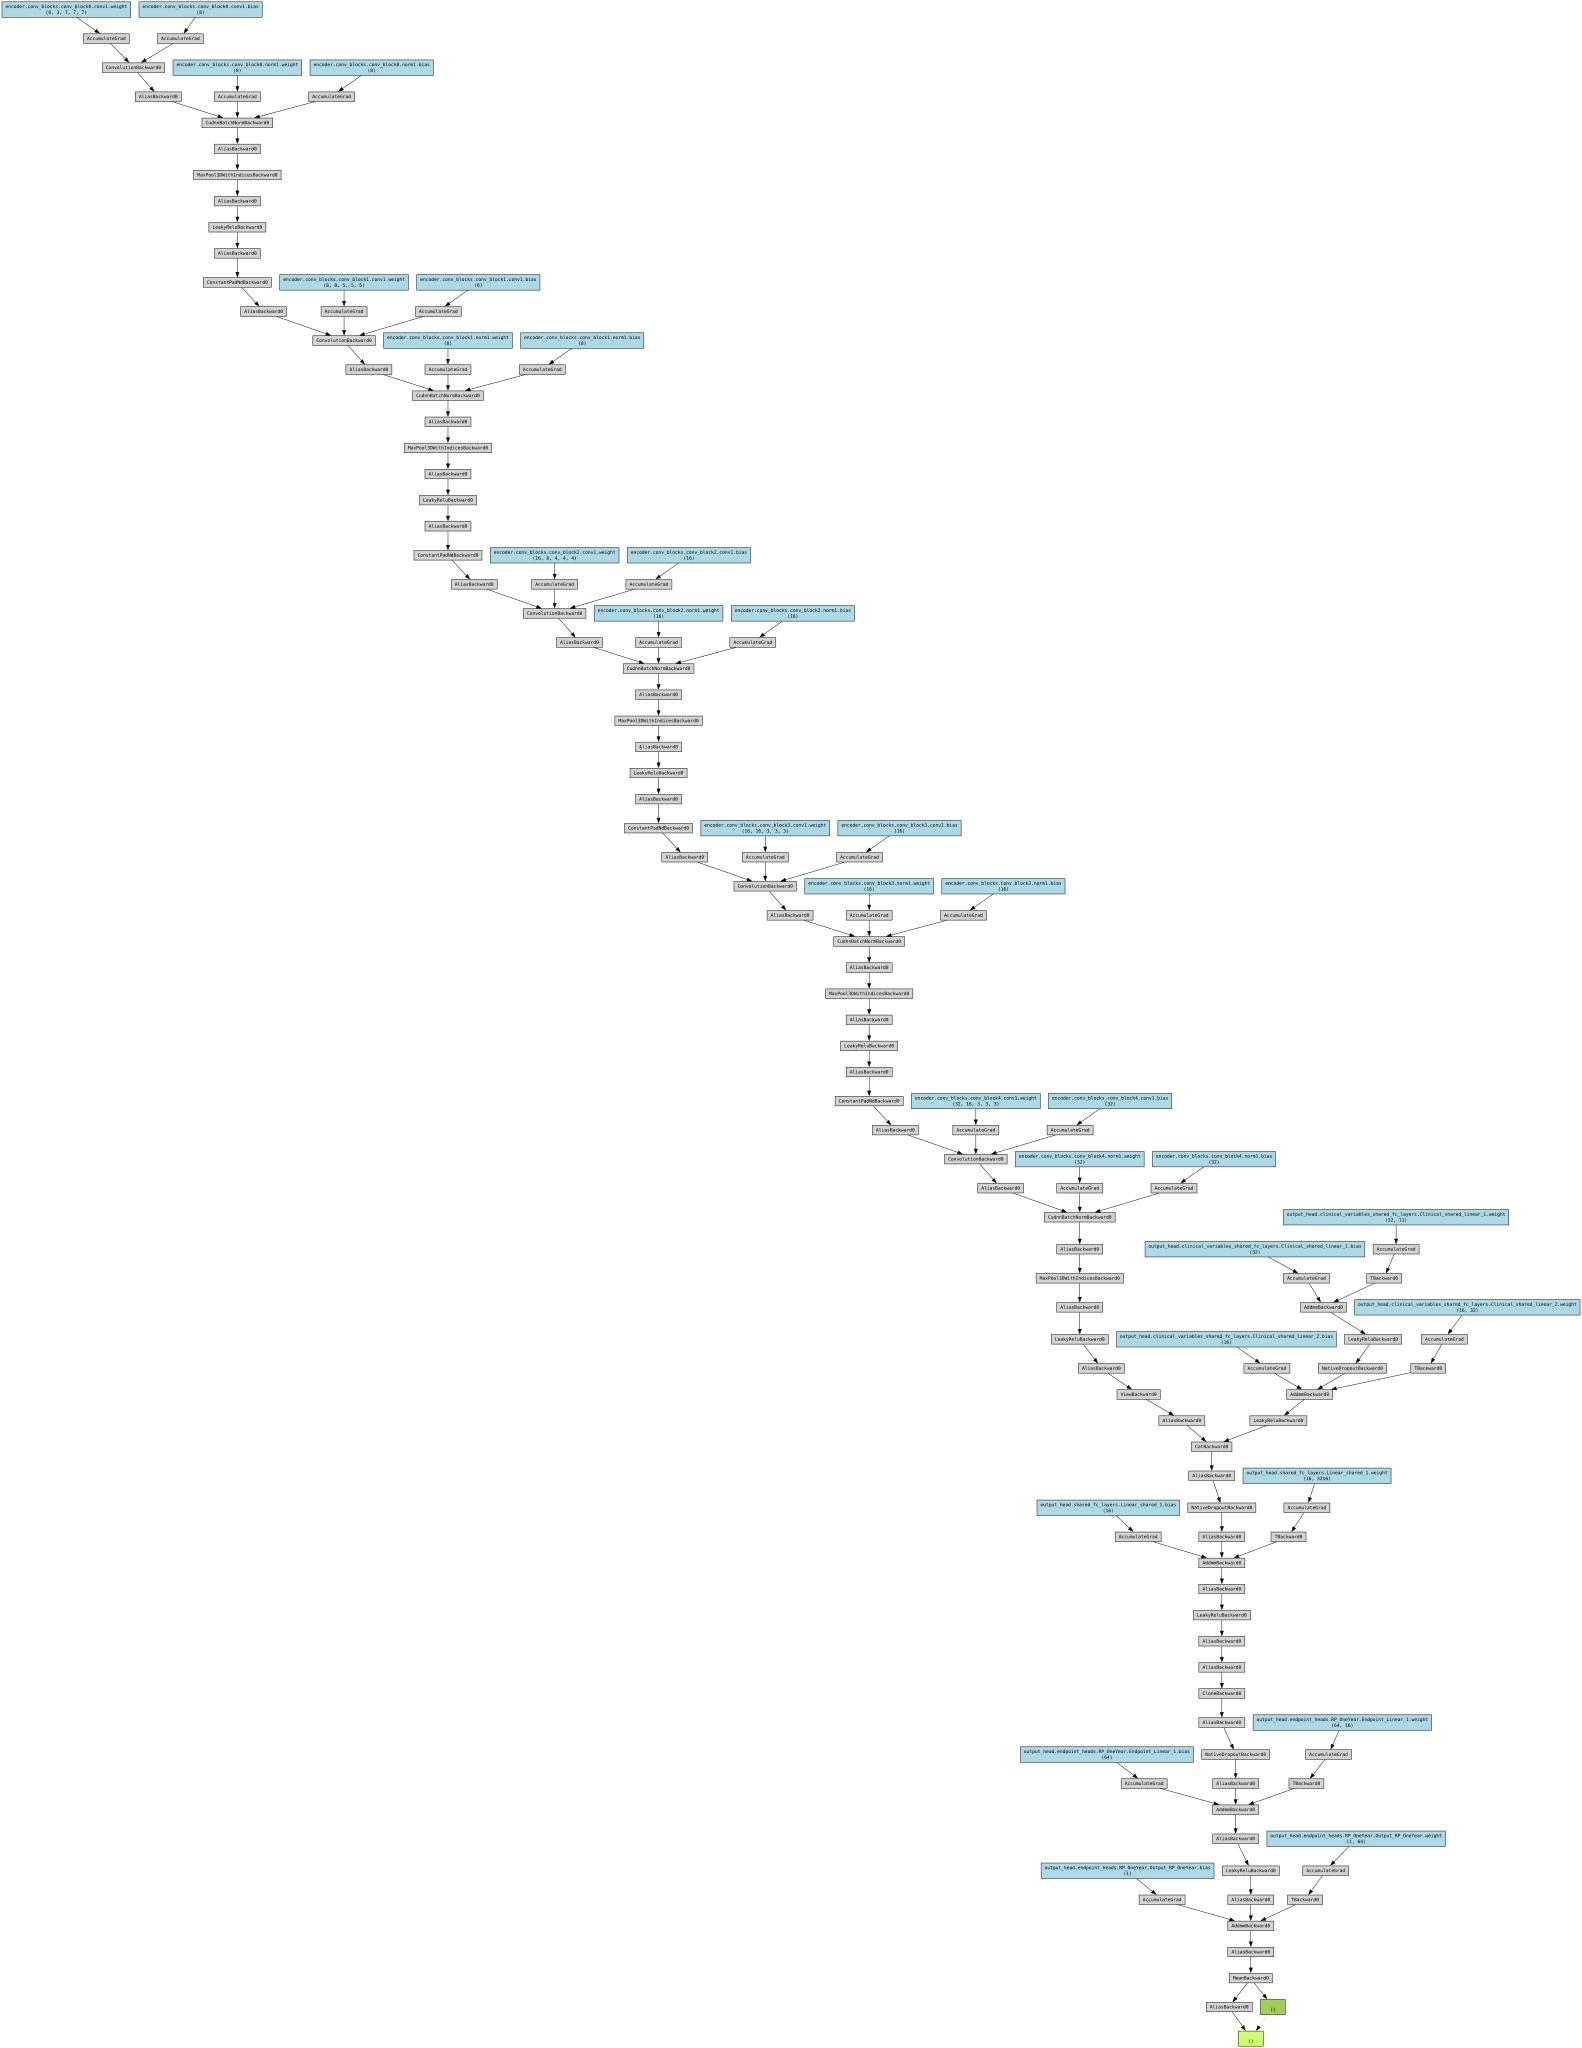

In [42]:
# Create the flowdiagram of the model ()
make_dot(outputs['RP_OneYear'].mean(),params=dict(model.named_parameters()))